In [2]:
%load_ext IPython.extensions.autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [3]:
import sys
sys.path.append('../')
from model import FinData
from model import train_valid_test_split
from model import CatboostFinModel, SVMFinModel

import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import pandas as pd

In [4]:
import json
import datetime as dt
import pandas as pd
from sklearn.metrics import precision_score, recall_score

In [5]:
def visualize_results_from_json(json_path):
    # Загрузка данных
    with open(json_path, 'r') as f:
        results = json.load(f)

    # --- precision/recall ---
    pr_df = pd.DataFrame(results["metrics"])
    pr_df['start_time'] = pd.to_datetime(pr_df['start_time'])
    pr_df = pr_df.sort_values('start_time')

    plt.figure(figsize=(12, 5))
    plt.plot(pr_df['start_time'], pr_df['precision'], marker='o', label='Precision')
    plt.plot(pr_df['start_time'], pr_df['recall'], marker='x', label='Recall')
    plt.title('Precision и Recall по 5-дневным окнам')
    plt.xlabel('Start Time')
    plt.ylabel('Значение')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(f"\nСредний precision: {pr_df['precision'].mean():.4f}")
    print(f"Средний recall: {pr_df['recall'].mean():.4f}")

    # --- Бюджет и PnL ---
    trade_df = pd.DataFrame(results["trading"])
    trade_df['start_time'] = pd.to_datetime(trade_df['start_time'])
    trade_df = trade_df.sort_values('start_time')

    plt.figure(figsize=(12, 5))
    plt.plot(trade_df['start_time'], trade_df['final_budget'], marker='s', color='green')
    plt.title('Динамика бюджета по стратегии')
    plt.xlabel('Start Time')
    plt.ylabel('Бюджет')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    pnl_total = trade_df['pnl'].sum()
    print(f"\nОбщая прибыль/убыток: {pnl_total:.2f}")

In [6]:
def run_experiments_through_time(args, model_сlass, df_path, start_time, end_time, json_out_path):
    cutoff_time = start_time - dt.timedelta(days=90)
    findata = FinData(df_path)
    findata.restrict_time_down(cutoff_time)
    findata.insert_all()

    cat_feats = findata.cat_features
    num_feats = findata.numeric_features
    target = 'direction_binary_0'

    initial_budget = 10000
    commission_rate = 0.0004
    budget = initial_budget

    curr_time = start_time
    predictions_list = []
    metrics_list = []
    trading_results_list = []

    while curr_time < end_time:
        data = findata.df
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]

        if test_df.empty:
            break

        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        model = model_сlass(args)
        model.set_datasets(X_train, X_val, y_train, y_val)
        model.set_features(num_feats, cat_feats)
        model.fit()

        proba = model.predict_proba(X_test)[:, 1]
        preds = (proba > 0.5).astype(int)

        temp_preds = pd.DataFrame({
            'utc': test_df['utc'].astype(str),
            'open': test_df['open'],
            'close': test_df['close'],
            'predicted_proba': proba,
            'predicted_label': preds,
            'true_label': y_test.values
        })
        predictions_list += temp_preds.to_dict(orient='records')

        # Precision и recall
        prec = precision_score(y_test, preds, zero_division=0)
        rec = recall_score(y_test, preds, zero_division=0)
        metrics_list.append({
            'start_time': str(curr_time),
            'end_time': str(curr_time + dt.timedelta(days=5)),
            'precision': prec,
            'recall': rec
        })

        test_df = test_df.reset_index(drop=True)  # на случай, если индекс не сброшен
        n = len(test_df)

        for i in range(n - 1):
            row = test_df.iloc[i]
            next_row = test_df.iloc[i + 1]

            price_now = row['close']
            price_next = next_row['close']
            signal = preds[i]  # предсказанный класс

            if signal == 1:
                n_shares = int(budget // price_now)
                if n_shares > 0:
                    buy_cost = n_shares * price_now * (1 + commission_rate)
                    sell_revenue = n_shares * price_next * (1 - commission_rate)
                    budget += sell_revenue - buy_cost
                    # Можно добавить лог транзакции, если хочешь сохранить его

        trading_results_list.append({
            'start_time': str(curr_time),
            'end_time': str(curr_time + dt.timedelta(days=5)),
            'final_budget': budget,
            'pnl': budget - initial_budget
        })

        curr_time += dt.timedelta(days=5)

    # Собираем в единый json-словарь
    output = {
        'predictions': predictions_list,
        'metrics': metrics_list,
        'trading': trading_results_list
    }

    with open(json_out_path, 'w') as f:
        json.dump(output, f, indent=2)

In [9]:
args1 = {
    "iterations": 10000,
    "depth": 2,
    "learning_rate": 0.02,
    "use_best_model": True,
    "l2_leaf_reg": 94,
    "loss_function": 'Logloss',
    "eval_metric": 'Logloss',
    "cat_features": [],
    "random_state": 42,
    "class_weights": [1, 0.34], 
    "verbose": 0,
    "early_stopping_rounds": 500
}

company_name = 'Gazprom'
df_path = '../datasets/' + company_name + '_1_min.csv'

start_time = dt.datetime(2024, 2, 1)
end_time = dt.datetime(2024, 4, 30)

run_experiments_through_time(args1, CatboostFinModel, df_path, start_time, end_time, 'cross_val.json')

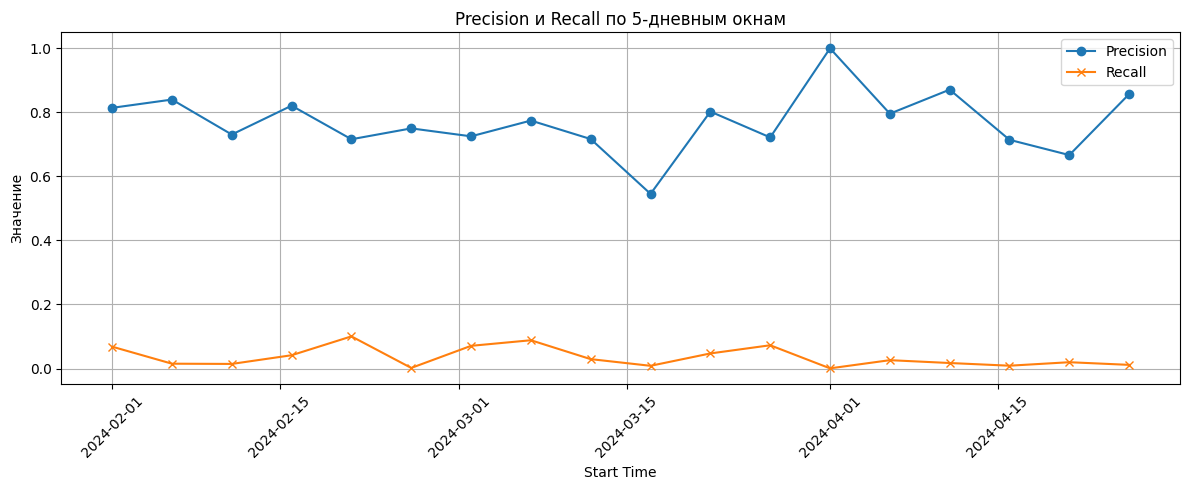


Средний precision: 0.7702
Средний recall: 0.0357


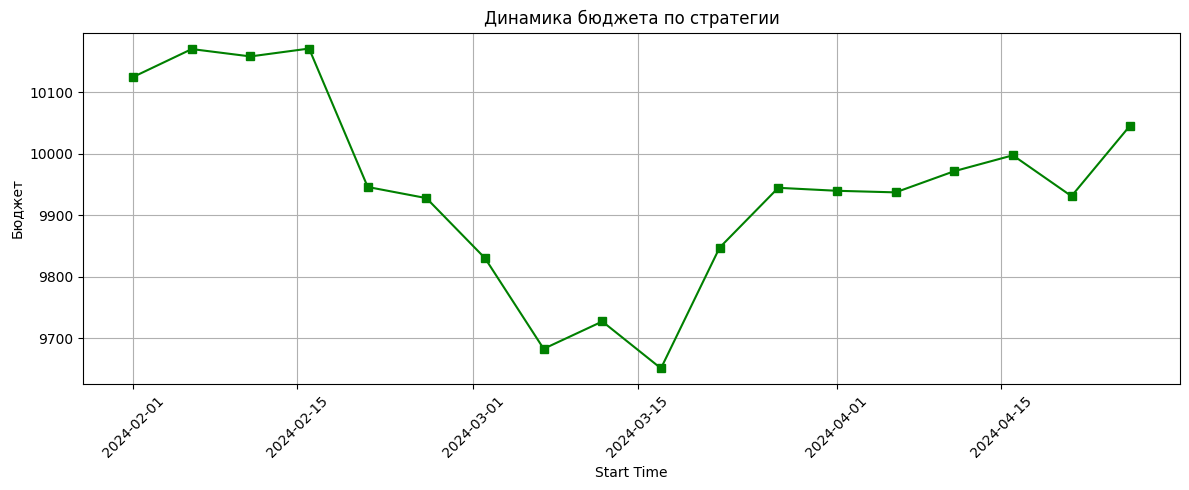


Общая прибыль/убыток: -996.13


In [10]:
visualize_results_from_json('cross_val.json')

In [9]:
args1 = {
    "iterations": 10000,
    "depth": 5,
    "learning_rate": 0.02,
    "use_best_model": True,
    "l2_leaf_reg": 200,
    "loss_function": 'Logloss',
    "eval_metric": 'Logloss',
    "cat_features": [],
    "random_state": 42,
    "class_weights": [1, 0.25], 
    "verbose": 0,
    "early_stopping_rounds": 500
}

company_name = 'Gazprom'
df_path = '../datasets/' + company_name + '_1_min.csv'

start_time = dt.datetime(2024, 2, 1)
end_time = dt.datetime(2024, 4, 30)

run_experiments_through_time(args1, CatboostFinModel, df_path, start_time, end_time, 'check.json')

In [12]:
def visualize_results_from_json(json_path):
    # Загрузка данных
    with open(json_path, 'r') as f:
        results = json.load(f)

    # --- precision/recall ---
    pr_df = pd.DataFrame(results["metrics"])
    pr_df['start_time'] = pd.to_datetime(pr_df['start_time'])
    pr_df = pr_df.sort_values('start_time')

    plt.figure(figsize=(12, 5))
    plt.plot(pr_df['start_time'], pr_df['precision'], marker='o', label='Precision')
    plt.plot(pr_df['start_time'], pr_df['recall'], marker='x', label='Recall')
    plt.title('Precision и Recall по 5-дневным окнам')
    plt.xlabel('Start Time')
    plt.ylabel('Значение')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(f"\nСредний precision: {pr_df['precision'].mean():.4f}")
    print(f"Средний recall: {pr_df['recall'].mean():.4f}")

    # --- Бюджет и PnL ---
    trade_df = pd.DataFrame(results["trading"])
    trade_df['start_time'] = pd.to_datetime(trade_df['start_time'])
    trade_df = trade_df.sort_values('start_time')

    plt.figure(figsize=(12, 5))
    plt.plot(trade_df['start_time'], trade_df['final_budget'], marker='s', color='green')
    plt.title('Динамика бюджета по стратегии')
    plt.xlabel('Start Time')
    plt.ylabel('Бюджет')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    pnl_total = trade_df['pnl'].sum()
    print(f"\nОбщая прибыль/убыток: {pnl_total:.2f}")

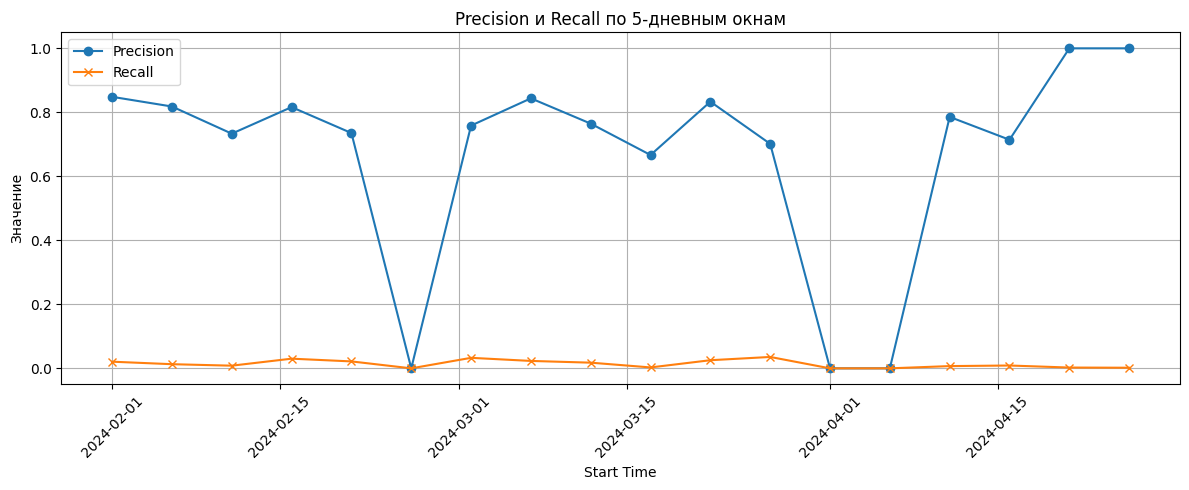


Средний precision: 0.6678
Средний recall: 0.0140


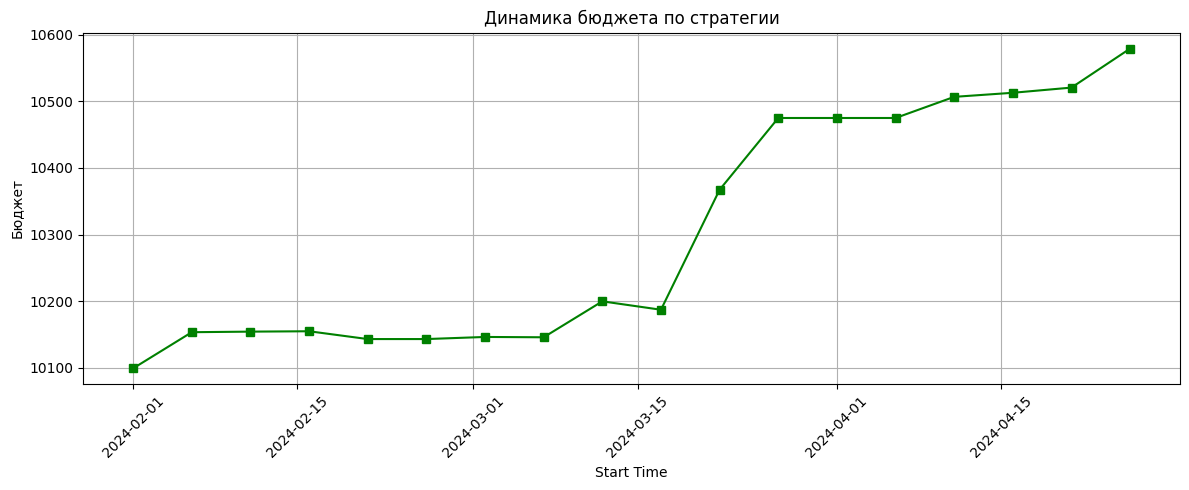


Общая прибыль/убыток: 5437.66


In [13]:
visualize_results_from_json('check.json')

In [5]:
import pandas as pd
import datetime as dt

args1 = {
    "iterations": 10000,
    "depth": 5,
    "learning_rate": 0.02,
    "use_best_model": True,
    "l2_leaf_reg": 200,
    "loss_function": 'Logloss',
    "eval_metric": 'Logloss',
    "cat_features": [],
    "random_state": 42,
    "class_weights": [1, 0.25], 
    "verbose": 0,
    "early_stopping_rounds": 500
}

companies_names = ['Gazprom']
dfs = ["../datasets/" + stock + '_1_min.csv' for stock in companies_names]

cutoff_time = dt.datetime(2023, 10, 1)
start_time = dt.datetime(2024, 2, 1)
end_time = dt.datetime(2024, 4, 30)

for i in range(len(dfs)):
    res = pd.DataFrame()
    findata = FinData(dfs[i])
    findata.restrict_time_down(cutoff_time)
    findata.insert_all()

    cat_feats = findata.cat_features
    num_feats = findata.numeric_features
    target = 'direction_binary_0'
    
    curr_time = start_time
    company_name = companies_names[i]

    while curr_time < end_time:
        data = findata.df
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        train_sd, val_sd, test_sd = train_df["utc"].iloc[0], val_df["utc"].iloc[0], test_df["utc"].iloc[0]
        train_ed, val_ed, test_ed = train_df["utc"].iloc[-1], val_df["utc"].iloc[-1], test_df["utc"].iloc[-1]
        print(f"Начало тренировочного периода: {train_sd}. Конец тренировочного периода: {train_ed} \n \
                    Начало валидационного периода: {val_sd}. Конец валидационного периода: {val_ed} \n \
                    Начало тестового периода: {test_sd}. Конец тестового периода: {test_ed} \n ")
        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        model = CatboostFinModel(args1)
        model.set_datasets(X_train, X_val, y_train, y_val)
        model.set_features(num_feats, cat_feats)
        model.fit()

        # Предсказания вероятностей класса 1
        proba = model.predict_proba(X_test)[:, 1]

        # Формирование блока с результатами
        temp_df = pd.DataFrame({
            'utc': test_df['utc'].values,
            'open': test_df['open'].values,
            'close': test_df['close'].values,
            'predicted_proba': proba
        })

        # Добавляем в общий DataFrame
        res = pd.concat([res, temp_df], ignore_index=True)

        # Сдвигаем окно
        curr_time += dt.timedelta(days=5)

    # Сохраняем результат по компании
    res.to_csv(f'{company_name}_long_valid.csv', index=False)


Начало тренировочного периода: 2023-12-28 07:01:00. Конец тренировочного периода: 2024-01-26 20:49:00 
                     Начало валидационного периода: 2024-01-27 07:01:00. Конец валидационного периода: 2024-01-31 20:49:00 
                     Начало тестового периода: 2024-02-01 07:00:00. Конец тестового периода: 2024-02-05 20:49:00 
 
Начало тренировочного периода: 2024-01-02 07:17:00. Конец тренировочного периода: 2024-01-31 20:49:00 
                     Начало валидационного периода: 2024-02-01 07:00:00. Конец валидационного периода: 2024-02-05 20:49:00 
                     Начало тестового периода: 2024-02-06 07:00:00. Конец тестового периода: 2024-02-10 16:00:00 
 
Начало тренировочного периода: 2024-01-07 07:01:00. Конец тренировочного периода: 2024-02-05 20:49:00 
                     Начало валидационного периода: 2024-02-06 07:00:00. Конец валидационного периода: 2024-02-10 16:00:00 
                     Начало тестового периода: 2024-02-11 07:07:00. Конец тестового пер

In [21]:
args1SWM = {
    'probability' : True
}

company_name = 'Gazprom'
df_path = '../datasets/' + company_name + '_1_min.csv'

start_time = dt.datetime(2024, 2, 1)
end_time = dt.datetime(2024, 4, 30)

run_experiments_through_time(args1SWM, SVMFinModel, df_path, start_time, end_time, 'SVM.json')

KeyboardInterrupt: 

C:\Users\Валерия\AppData\Local\Temp\ipykernel_11988\1040248443.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_accuracy = data.groupby('group_id').apply(compute_group_accuracy).reset_index()


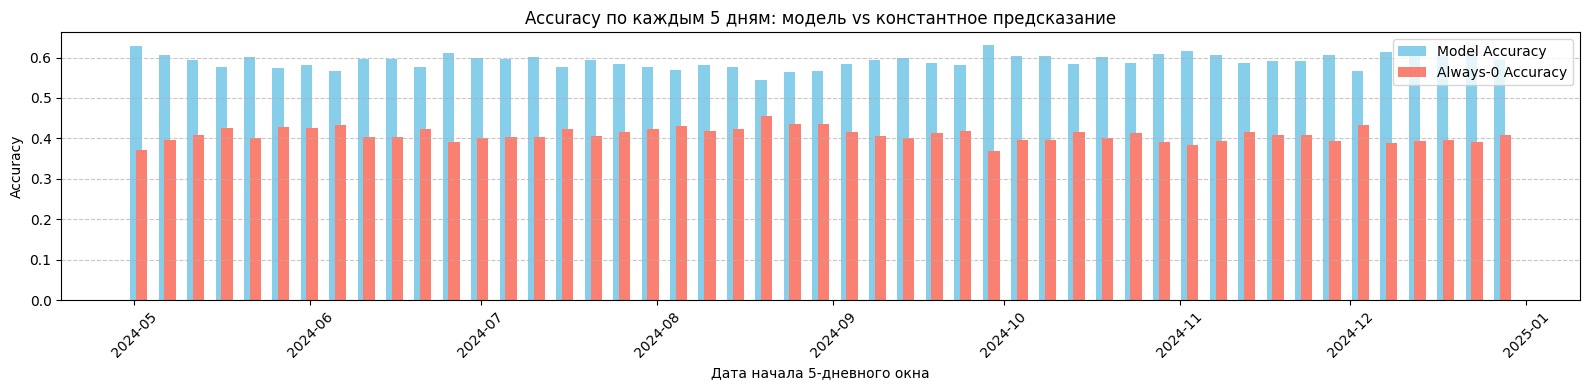

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Загрузка и подготовка данных
data = pd.read_csv('Whoosh_short_valid.csv')
data['utc'] = pd.to_datetime(data['utc'])
data = data.sort_values('utc')

# Целевая переменная: будет ли close расти на следующей минуте
data['target'] = (data['close'].shift(-1) >= data['close']).astype(int)

# Предсказания модели
threshold = 0.5
data['pred'] = (data['predicted_proba'] > threshold).astype(int)

# Создаем группы по 5 дней
data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)

# Функция для расчёта accuracy модели и accuracy "всегда 0"
def compute_group_accuracy(group):
    acc_model = accuracy_score(group['target'], group['pred'])
    acc_dummy0 = accuracy_score(group['target'], [0] * len(group))
    return pd.Series({'accuracy_model': acc_model, 'accuracy_dummy0': acc_dummy0})

# Применяем по группам
grouped_accuracy = data.groupby('group_id').apply(compute_group_accuracy).reset_index()

# Добавим дату начала группы
grouped_accuracy['start_date'] = data.groupby('group_id')['utc'].min().values

# Строим barplot
plt.figure(figsize=(16, 4))
bar_width = 4  # Ширина одного столбца (в днях на оси X)

# Координаты по оси X
x = grouped_accuracy['start_date']

# Столбцы с accuracy модели (слева) и dummy (чуть правее)
plt.bar(x, grouped_accuracy['accuracy_model'], 
        width=2, label='Model Accuracy', color='skyblue', align='center')

plt.bar(x, grouped_accuracy['accuracy_dummy0'], 
        width=2, label='Always-0 Accuracy', color='salmon', align='edge')

# Подписи и оформление
plt.title('Accuracy по каждым 5 дням: модель vs константное предсказание')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\Валерия\AppData\Local\Temp\ipykernel_11988\4288904023.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_by_group = data.groupby('group_id').apply(compute_precision_recall).reset_index()


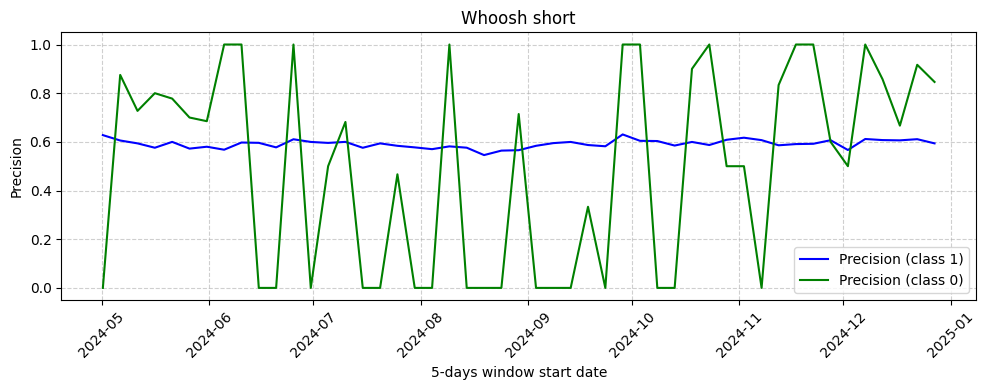

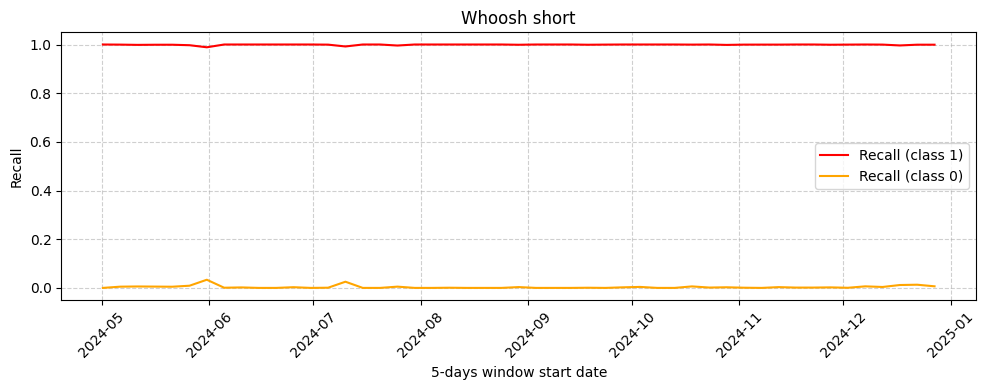

In [28]:
from sklearn.metrics import precision_score, recall_score

# Группировка по 5-дневным окнам
data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)

# Функция для расчета precision и recall по классам
def compute_precision_recall(group):
    y_true = group['target']
    y_pred = group['pred']
    precision_1 = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    precision_0 = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    recall_1 = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall_0 = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    return pd.Series({
        'precision_1': precision_1,
        'precision_0': precision_0,
        'recall_1': recall_1,
        'recall_0': recall_0
    })

# Применяем по группам
metrics_by_group = data.groupby('group_id').apply(compute_precision_recall).reset_index()

# Добавим дату начала каждой группы
metrics_by_group['start_date'] = data.groupby('group_id')['utc'].min().values

# ----------------------- #
# 1. График Precision     #
# ----------------------- #
plt.figure(figsize=(10, 4))
plt.plot(metrics_by_group['start_date'], metrics_by_group['precision_1'], label='Precision (class 1)', color='blue')
plt.plot(metrics_by_group['start_date'], metrics_by_group['precision_0'], label='Precision (class 0)', color='green')
plt.title('Whoosh short')
plt.xlabel('5-days window start date')
plt.ylabel('Precision')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------- #
# 2. График Recall        #
# ----------------------- #
plt.figure(figsize=(10, 4))
plt.plot(metrics_by_group['start_date'], metrics_by_group['recall_1'], label='Recall (class 1)', color='red')
plt.plot(metrics_by_group['start_date'], metrics_by_group['recall_0'], label='Recall (class 0)', color='orange')
plt.title('Whoosh short')
plt.xlabel('5-days window start date')
plt.ylabel('Recall')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

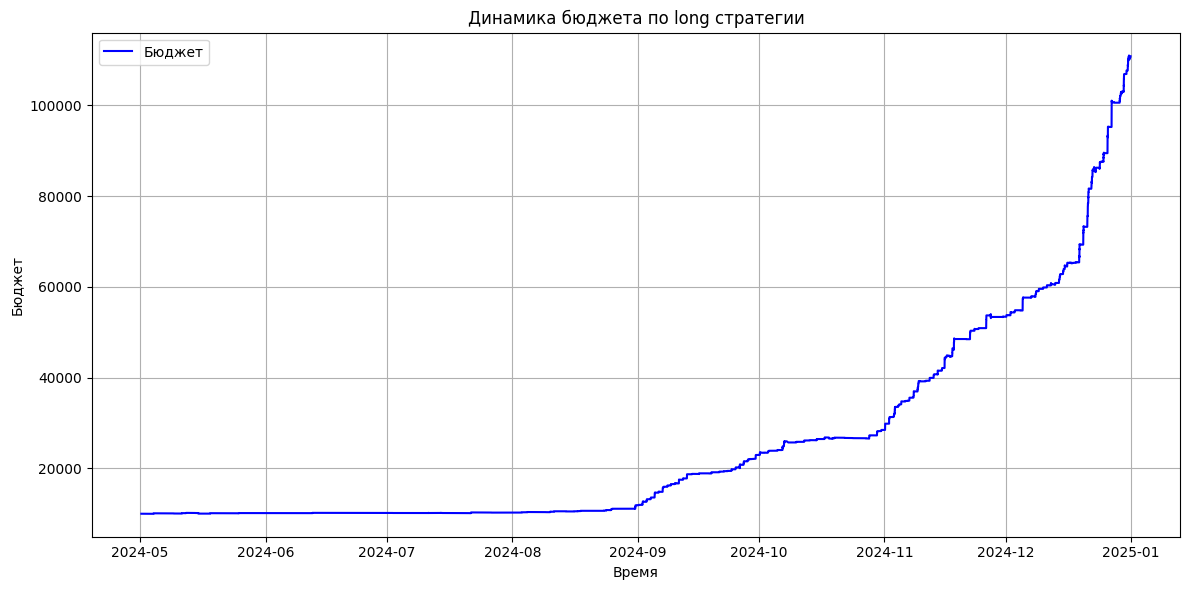

In [30]:
# Загрузка и подготовка данных
data = pd.read_csv('Whoosh_long_valid.csv')
data['utc'] = pd.to_datetime(data['utc'])
data = data.sort_values('utc')

# Целевая переменная: будет ли close расти на следующей минуте
data['target'] = (data['close'].shift(-1) >= data['close']).astype(int)

# Предсказания модели
threshold = 0.5
data['pred'] = (data['predicted_proba'] > threshold).astype(int)

# Создаем группы по 5 дней
data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)

merged = data

# Добавим колонку close_{t+1}
merged['close_t+1'] = merged['close'].shift(-1)

df = merged

df['predicted_class'] = df['pred']

# Параметры
initial_budget = 10000
commission_rate = 0.0004

budget = initial_budget
budget_history = [budget]
timestamps = [df['utc'].iloc[0]]

for i in range(len(df) - 1):
    # continue
    row = df.iloc[i]
    next_row = df.iloc[i + 1]

    price_now = row['close']
    price_next = next_row['close']
    signal = row['predicted_class']

    if signal == 1:  # Long
        n_shares = int(budget // price_now)
        if n_shares == 0:
            pass
        else:
            buy_cost = n_shares * price_now * (1 + commission_rate)
            sell_revenue = n_shares * price_next * (1 - commission_rate)
            budget += sell_revenue - buy_cost

    # if signal == 0:  # Short
    #     n_shares = int(budget // price_now)
    #     if n_shares == 0:
    #         pass
    #     else:
    #         sell_proceeds = n_shares * price_now * (1 - commission_rate)
    #         buy_cost = n_shares * price_next * (1 + commission_rate)
    #         budget += sell_proceeds - buy_cost

    # Если signal == 0 — ничего не делаем
    budget_history.append(budget)
    timestamps.append(next_row['utc'])

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(timestamps, budget_history, label='Бюджет', color='blue')
plt.xlabel('Время')
plt.ylabel('Бюджет')
plt.title('Динамика бюджета по long стратегии')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


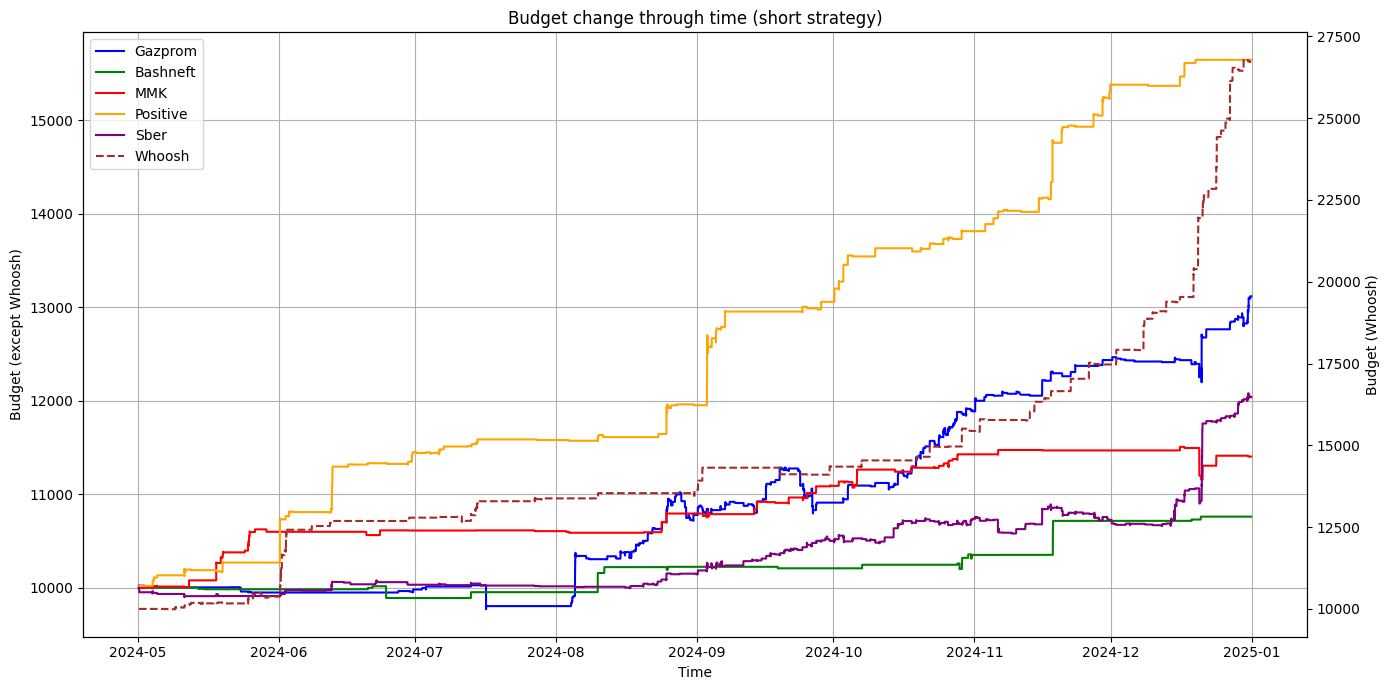

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Список всех датасетов
files = [
    'Gazprom_short_valid.csv',
    'Bashneft_short_valid.csv',
    'MMK_short_valid.csv',
    'Positive_short_valid.csv',
    'Sber_short_valid.csv',
    'Whoosh_short_valid.csv'
]

colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']
labels = ['Gazprom', 'Bashneft', 'MMK', 'Positive', 'Sber', 'Whoosh']

# Создаем основной график и вторую ось для Whoosh
fig, ax_left = plt.subplots(figsize=(14, 7))
ax_right = ax_left.twinx()

# Комиссия и старт
initial_budget = 10000
commission_rate = 0.0004

for i, file in enumerate(files):
    data = pd.read_csv(file)
    data['utc'] = pd.to_datetime(data['utc'])
    data = data.sort_values('utc')
    data['target'] = (data['close'].shift(-1) >= data['close']).astype(int)
    data['pred'] = (data['predicted_proba'] > 0.5).astype(int)
    data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)
    data['close_t+1'] = data['close'].shift(-1)
    data['predicted_class'] = data['pred']

    budget = initial_budget
    budget_history = [budget]
    timestamps = [data['utc'].iloc[0]]

    for j in range(len(data) - 1):
        row = data.iloc[j]
        next_row = data.iloc[j + 1]

        price_now = row['close']
        price_next = next_row['close']
        signal = row['predicted_class']

        if signal == 0:  # Short
            n_shares = int(budget // price_now)
            if n_shares == 0:
                pass
            else:
                sell_proceeds = n_shares * price_now * (1 - commission_rate)
                buy_cost = n_shares * price_next * (1 + commission_rate)
                budget += sell_proceeds - buy_cost

        budget_history.append(budget)
        timestamps.append(next_row['utc'])

    # Отрисовка: Whoosh — на правой оси, остальные — на левой
    if file == 'Whoosh_short_valid.csv':
        ax_right.plot(timestamps, budget_history, label=labels[i], color=colors[i], linestyle='--')
    else:
        ax_left.plot(timestamps, budget_history, label=labels[i], color=colors[i])

# Подписи и оформление
ax_left.set_xlabel('Time')
ax_left.set_ylabel('Budget (except Whoosh)', color='black')
ax_right.set_ylabel('Budget (Whoosh)', color='black')
ax_left.grid(True)

# Объединенная легенда
lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc='upper left')

plt.title('Budget change through time (short strategy)')
plt.tight_layout()
plt.show()


In [15]:
import pandas as pd
import datetime as dt

args1 = {
    "iterations": 10000,
    "depth": 5,
    "learning_rate": 0.02,
    "use_best_model": True,
    "l2_leaf_reg": 200,
    "loss_function": 'Logloss',
    "eval_metric": 'Logloss',
    "random_state": 42,
    "verbose": 0,
    "class_weights" : [1, 0.25], 
    "early_stopping_rounds": 500
}

companies_names = ['Gazprom']
dfs = ["../datasets/" + stock + '_1_min.csv' for stock in companies_names]

cutoff_time = dt.datetime(2023, 10, 1)
start_time = dt.datetime(2024, 2, 1)
end_time = dt.datetime(2024, 2, 29)

for i in range(len(dfs)):
    res = pd.DataFrame()
    findata = FinData(dfs[i])
    findata.restrict_time_down(cutoff_time)
    findata.insert_all()

    cat_feats = findata.cat_features
    num_feats = findata.numeric_features
    target = 'direction_binary_0'
    
    curr_time = start_time
    company_name = companies_names[i]

    while curr_time < end_time:
        data = findata.df
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        train_sd, val_sd, test_sd = train_df["utc"].iloc[0], val_df["utc"].iloc[0], test_df["utc"].iloc[0]
        train_ed, val_ed, test_ed = train_df["utc"].iloc[-1], val_df["utc"].iloc[-1], test_df["utc"].iloc[-1]
        print(f"Начало тренировочного периода: {train_sd}. Конец тренировочного периода: {train_ed} \n \
                    Начало валидационного периода: {val_sd}. Конец валидационного периода: {val_ed} \n \
                    Начало тестового периода: {test_sd}. Конец тестового периода: {test_ed} \n ")
        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        model = CatboostFinModel(args1)
        model.set_datasets(X_train, X_val, y_train, y_val)
        model.set_features(num_feats, cat_feats)
        model.fit()

        # Предсказания вероятностей класса 1
        proba = model.predict_proba(X_test)[:, 1]

        # Формирование блока с результатами
        temp_df = pd.DataFrame({
            'utc': test_df['utc'].values,
            'open': test_df['open'].values,
            'close': test_df['close'].values,
            'predicted_proba': proba
        })

        # Добавляем в общий DataFrame
        res = pd.concat([res, temp_df], ignore_index=True)

        # Сдвигаем окно
        curr_time += dt.timedelta(days=5)

    # Сохраняем результат по компании
    res.to_csv(f'{company_name}_long_valid_exp_2.csv', index=False)


Начало тренировочного периода: 2023-12-28 07:01:00. Конец тренировочного периода: 2024-01-26 20:49:00 
                     Начало валидационного периода: 2024-01-27 07:01:00. Конец валидационного периода: 2024-01-31 20:49:00 
                     Начало тестового периода: 2024-02-01 07:00:00. Конец тестового периода: 2024-02-05 20:49:00 
 
Начало тренировочного периода: 2024-01-02 07:17:00. Конец тренировочного периода: 2024-01-31 20:49:00 
                     Начало валидационного периода: 2024-02-01 07:00:00. Конец валидационного периода: 2024-02-05 20:49:00 
                     Начало тестового периода: 2024-02-06 07:00:00. Конец тестового периода: 2024-02-10 16:00:00 
 
Начало тренировочного периода: 2024-01-07 07:01:00. Конец тренировочного периода: 2024-02-05 20:49:00 
                     Начало валидационного периода: 2024-02-06 07:00:00. Конец валидационного периода: 2024-02-10 16:00:00 
                     Начало тестового периода: 2024-02-11 07:07:00. Конец тестового пер

In [ ]:
import pandas as pd
import datetime as dt

args1 = {
    "iterations": 10000,
    "depth": 5,
    "learning_rate": 0.02,
    "use_best_model": True,
    "l2_leaf_reg": 200,
    "loss_function": 'Logloss',
    "eval_metric": 'Logloss',
    "random_state": 42,
    "verbose": 0,
    "early_stopping_rounds": 500
}

companies_names = ['Gazprom']
dfs = ["../datasets/" + stock + '_1_min.csv' for stock in companies_names]

cutoff_time = dt.datetime(2023, 10, 1)
start_time = dt.datetime(2024, 2, 1)
end_time = dt.datetime(2024, 2, 29)

for i in range(len(dfs)):
    res = pd.DataFrame()
    findata = FinData(dfs[i])
    findata.restrict_time_down(cutoff_time)
    findata.insert_all()

    cat_feats = findata.cat_features
    num_feats = findata.numeric_features
    target = 'direction_binary_0'
    
    curr_time = start_time
    company_name = companies_names[i]

    while curr_time < end_time:
        data = findata.df
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        train_sd, val_sd, test_sd = train_df["utc"].iloc[0], val_df["utc"].iloc[0], test_df["utc"].iloc[0]
        train_ed, val_ed, test_ed = train_df["utc"].iloc[-1], val_df["utc"].iloc[-1], test_df["utc"].iloc[-1]
        print(f"Начало тренировочного периода: {train_sd}. Конец тренировочного периода: {train_ed} \n \
                    Начало валидационного периода: {val_sd}. Конец валидационного периода: {val_ed} \n \
                    Начало тестового периода: {test_sd}. Конец тестового периода: {test_ed} \n ")
        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        sample_weights_train = pd.Series(1.0, index=train_df.index)
        sample_weights_val = pd.Series(1.0, index=val_df.index)  # новый код
        
        mask_train = train_df['close'].shift(-1) > train_df['close']
        mask_val = val_df['close'].shift(-1) > val_df['close']  # новый код
        
        sample_weights_train.loc[mask_train] = 0.25
        sample_weights_val.loc[mask_val] = 0.25  # новый код

        model = CatboostFinModel(args1)
        model.set_datasets(X_train, X_val, y_train, y_val)
        model.set_features(num_feats, cat_feats)
        model.fit(sample_weights_train=sample_weights_train, sample_weights_val=sample_weights_val)
        # Предсказания вероятностей класса 1
        proba = model.predict_proba(X_test)[:, 1]

        # Формирование блока с результатами
        temp_df = pd.DataFrame({
            'utc': test_df['utc'].values,
            'open': test_df['open'].values,
            'close': test_df['close'].values,
            'predicted_proba': proba
        })

        # Добавляем в общий DataFrame
        res = pd.concat([res, temp_df], ignore_index=True)

        # Сдвигаем окно
        curr_time += dt.timedelta(days=5)

    # Сохраняем результат по компании
    res.to_csv(f'{company_name}_long_valid_exp_3.csv', index=False)


Начало тренировочного периода: 2023-12-28 07:01:00. Конец тренировочного периода: 2024-01-26 20:49:00 
                     Начало валидационного периода: 2024-01-27 07:01:00. Конец валидационного периода: 2024-01-31 20:49:00 
                     Начало тестового периода: 2024-02-01 07:00:00. Конец тестового периода: 2024-02-05 20:49:00 
 
Начало тренировочного периода: 2024-01-02 07:17:00. Конец тренировочного периода: 2024-01-31 20:49:00 
                     Начало валидационного периода: 2024-02-01 07:00:00. Конец валидационного периода: 2024-02-05 20:49:00 
                     Начало тестового периода: 2024-02-06 07:00:00. Конец тестового периода: 2024-02-10 16:00:00 
 
Начало тренировочного периода: 2024-01-07 07:01:00. Конец тренировочного периода: 2024-02-05 20:49:00 
                     Начало валидационного периода: 2024-02-06 07:00:00. Конец валидационного периода: 2024-02-10 16:00:00 
                     Начало тестового периода: 2024-02-11 07:07:00. Конец тестового пер

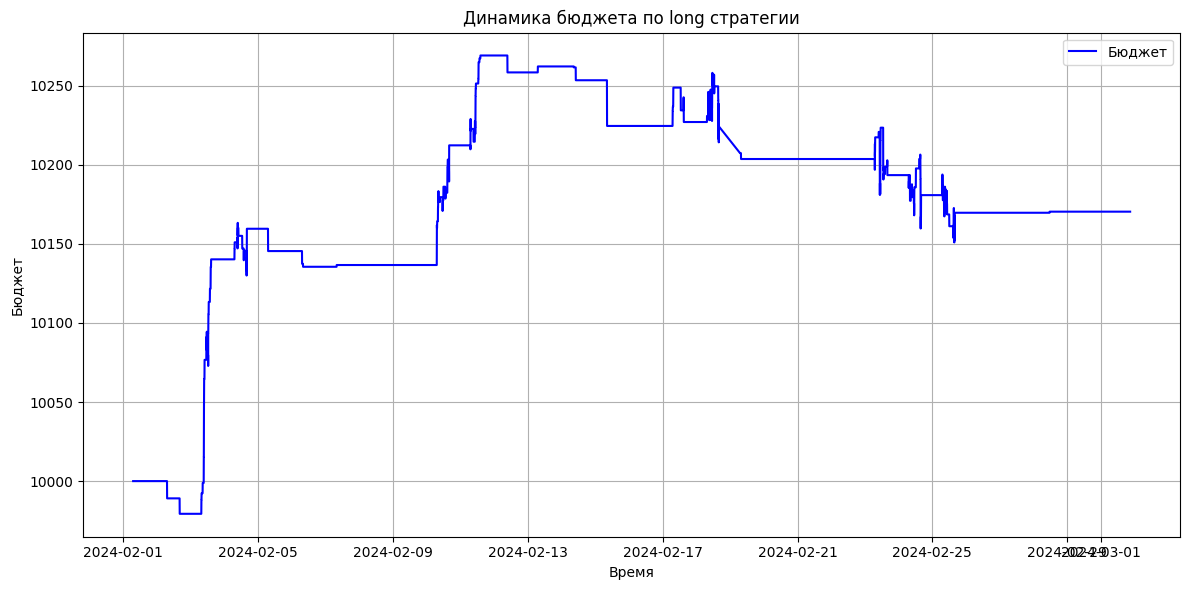

In [7]:
# Загрузка и подготовка данных
data = pd.read_csv('Gazprom_long_valid_exp_1.csv')
data['utc'] = pd.to_datetime(data['utc'])
data = data.sort_values('utc')

# Целевая переменная: будет ли close расти на следующей минуте
data['target'] = (data['close'].shift(-1) >= data['close']).astype(int)

# Предсказания модели
threshold = 0.5
data['pred'] = (data['predicted_proba'] > threshold).astype(int)

# Создаем группы по 5 дней
data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)

merged = data

# Добавим колонку close_{t+1}
merged['close_t+1'] = merged['close'].shift(-1)

df = merged

df['predicted_class'] = df['pred']

# Параметры
initial_budget = 10000
commission_rate = 0.0004

budget = initial_budget
budget_history = [budget]
timestamps = [df['utc'].iloc[0]]

for i in range(len(df) - 1):
    # continue
    row = df.iloc[i]
    next_row = df.iloc[i + 1]

    price_now = row['close']
    price_next = next_row['close']
    signal = row['predicted_class']

    if signal == 1:  # Long
        n_shares = int(budget // price_now)
        if n_shares == 0:
            pass
        else:
            buy_cost = n_shares * price_now * (1 + commission_rate)
            sell_revenue = n_shares * price_next * (1 - commission_rate)
            budget += sell_revenue - buy_cost

    # if signal == 0:  # Short
    #     n_shares = int(budget // price_now)
    #     if n_shares == 0:
    #         pass
    #     else:
    #         sell_proceeds = n_shares * price_now * (1 - commission_rate)
    #         buy_cost = n_shares * price_next * (1 + commission_rate)
    #         budget += sell_proceeds - buy_cost

    # Если signal == 0 — ничего не делаем
    budget_history.append(budget)
    timestamps.append(next_row['utc'])

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(timestamps, budget_history, label='Бюджет', color='blue')
plt.xlabel('Время')
plt.ylabel('Бюджет')
plt.title('Динамика бюджета по long стратегии')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

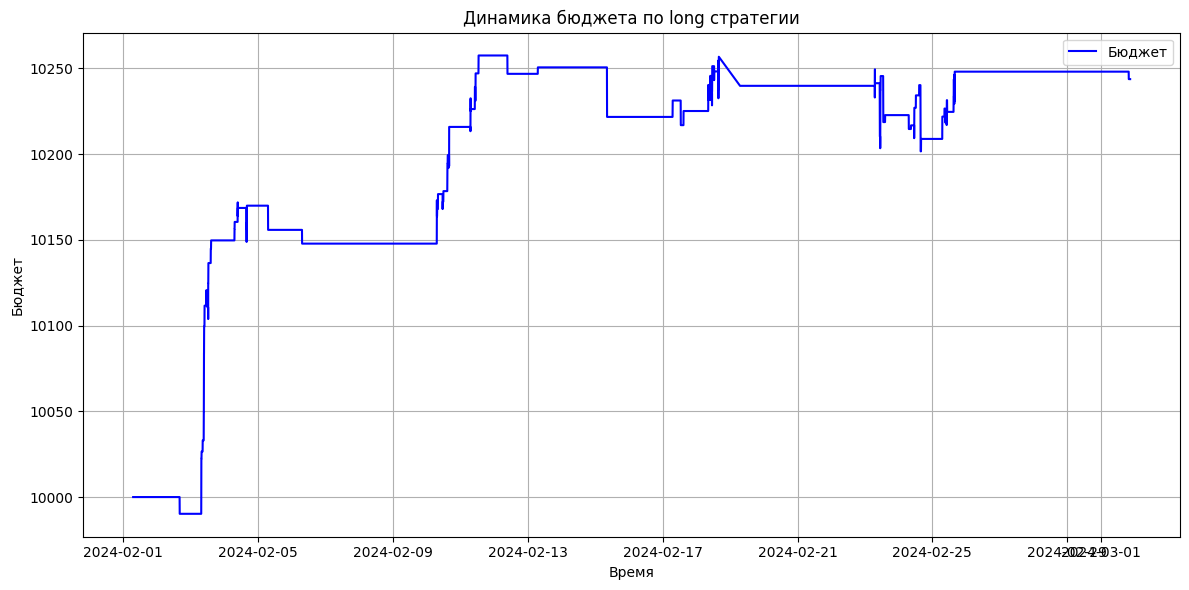

In [9]:
# Загрузка и подготовка данных
data = pd.read_csv('Gazprom_long_valid_exp_3.csv')
data['utc'] = pd.to_datetime(data['utc'])
data = data.sort_values('utc')

# Целевая переменная: будет ли close расти на следующей минуте
data['target'] = (data['close'].shift(-1) >= data['close']).astype(int)

# Предсказания модели
threshold = 0.5
data['pred'] = (data['predicted_proba'] > threshold).astype(int)

# Создаем группы по 5 дней
data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)

merged = data

# Добавим колонку close_{t+1}
merged['close_t+1'] = merged['close'].shift(-1)

df = merged

df['predicted_class'] = df['pred']

# Параметры
initial_budget = 10000
commission_rate = 0.0004

budget = initial_budget
budget_history = [budget]
timestamps = [df['utc'].iloc[0]]

for i in range(len(df) - 1):
    # continue
    row = df.iloc[i]
    next_row = df.iloc[i + 1]

    price_now = row['close']
    price_next = next_row['close']
    signal = row['predicted_class']

    if signal == 1:  # Long
        n_shares = int(budget // price_now)
        if n_shares == 0:
            pass
        else:
            buy_cost = n_shares * price_now * (1 + commission_rate)
            sell_revenue = n_shares * price_next * (1 - commission_rate)
            budget += sell_revenue - buy_cost

    # if signal == 0:  # Short
    #     n_shares = int(budget // price_now)
    #     if n_shares == 0:
    #         pass
    #     else:
    #         sell_proceeds = n_shares * price_now * (1 - commission_rate)
    #         buy_cost = n_shares * price_next * (1 + commission_rate)
    #         budget += sell_proceeds - buy_cost

    # Если signal == 0 — ничего не делаем
    budget_history.append(budget)
    timestamps.append(next_row['utc'])

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(timestamps, budget_history, label='Бюджет', color='blue')
plt.xlabel('Время')
plt.ylabel('Бюджет')
plt.title('Динамика бюджета по long стратегии')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
def visualise_short_budget(res_short_csv_path):
    # Загрузка и подготовка данных
    data = pd.read_csv(res_short_csv_path)
    data['utc'] = pd.to_datetime(data['utc'])
    data = data.sort_values('utc')
    # Предсказания модели
    threshold = 0.5
    data['pred'] = (data['predicted_proba'] > threshold).astype(int)

    # Создаем группы по 5 дней
    data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)

    merged = data

    # Добавим колонку close_{t+1}
    merged['close_t+1'] = merged['close'].shift(-1)

    df = merged

    df['predicted_class'] = df['pred']

    # Параметры
    initial_budget = 10000
    commission_rate = 0.0004

    budget = initial_budget
    budget_history = [budget]
    timestamps = [df['utc'].iloc[0]]

    for i in range(len(df) - 1):
        # continue
        row = df.iloc[i]
        next_row = df.iloc[i + 1]

        price_now = row['close']
        price_next = next_row['close']
        signal = row['predicted_class']

        # if signal == 1:  # Long
        #     n_shares = int(budget // price_now)
        #     if n_shares == 0:
        #         pass
        #     else:
        #         buy_cost = n_shares * price_now * (1 + commission_rate)
        #         sell_revenue = n_shares * price_next * (1 - commission_rate)
        #         budget += sell_revenue - buy_cost

        if signal == 0:  # Short
            n_shares = int(budget // price_now)
            if n_shares == 0:
                pass
            else:
                sell_proceeds = n_shares * price_now * (1 - commission_rate)
                buy_cost = n_shares * price_next * (1 + commission_rate)
                budget += sell_proceeds - buy_cost

        # Если signal == 0 — ничего не делаем
        budget_history.append(budget)
        timestamps.append(next_row['utc'])

    # Визуализация
    plt.figure(figsize=(12, 6))
    plt.plot(timestamps, budget_history, label='Бюджет', color='blue')
    plt.xlabel('Время')
    plt.ylabel('Бюджет')
    plt.title('Динамика бюджета по long стратегии')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    

In [14]:
def visualise_long_budget(res_long_csv_path):
    # Загрузка и подготовка данных
    data = pd.read_csv(res_long_csv_path)
    data['utc'] = pd.to_datetime(data['utc'])
    data = data.sort_values('utc')
    # Предсказания модели
    threshold = 0.5
    data['pred'] = (data['predicted_proba'] > threshold).astype(int)

    # Создаем группы по 5 дней
    data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)

    merged = data

    # Добавим колонку close_{t+1}
    merged['close_t+1'] = merged['close'].shift(-1)

    df = merged

    df['predicted_class'] = df['pred']

    # Параметры
    initial_budget = 10000
    commission_rate = 0.0004

    budget = initial_budget
    budget_history = [budget]
    timestamps = [df['utc'].iloc[0]]

    for i in range(len(df) - 1):
        # continue
        row = df.iloc[i]
        next_row = df.iloc[i + 1]

        price_now = row['close']
        price_next = next_row['close']
        signal = row['predicted_class']

        if signal == 1:  # Long
            n_shares = int(budget // price_now)
            if n_shares == 0:
                pass
            else:
                buy_cost = n_shares * price_now * (1 + commission_rate)
                sell_revenue = n_shares * price_next * (1 - commission_rate)
                budget += sell_revenue - buy_cost

        # if signal == 0:  # Short
        #     n_shares = int(budget // price_now)
        #     if n_shares == 0:
        #         pass
        #     else:
        #         sell_proceeds = n_shares * price_now * (1 - commission_rate)
        #         buy_cost = n_shares * price_next * (1 + commission_rate)
        #         budget += sell_proceeds - buy_cost

        # Если signal == 0 — ничего не делаем
        budget_history.append(budget)
        timestamps.append(next_row['utc'])

    # Визуализация
    plt.figure(figsize=(12, 6))
    plt.plot(timestamps, budget_history, label='Бюджет', color='blue')
    plt.xlabel('Время')
    plt.ylabel('Бюджет')
    plt.title('Динамика бюджета по long стратегии')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    

#### Повышение веса для значимых положительных изменений

In [20]:
import pandas as pd
import datetime as dt

args1 = {
    "iterations": 10000,
    "depth": 5,
    "learning_rate": 0.02,
    "use_best_model": True,
    "l2_leaf_reg": 200,
    "loss_function": 'Logloss',
    "eval_metric": 'Logloss',
    "random_state": 42,
    "verbose": 0,
    "early_stopping_rounds": 500
}

companies_names = ['Gazprom']
dfs = ["../datasets/" + stock + '_1_min.csv' for stock in companies_names]

cutoff_time = dt.datetime(2023, 10, 1)
start_time = dt.datetime(2024, 2, 1)
end_time = dt.datetime(2024, 2, 29)

for i in range(len(dfs)):
    res = pd.DataFrame()
    findata = FinData(dfs[i])
    findata.restrict_time_down(cutoff_time)
    findata.insert_all()

    cat_feats = findata.cat_features
    num_feats = findata.numeric_features
    target = 'direction_binary_0'
    
    curr_time = start_time
    company_name = companies_names[i]

    while curr_time < end_time:
        data = findata.df
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        train_sd, val_sd, test_sd = train_df["utc"].iloc[0], val_df["utc"].iloc[0], test_df["utc"].iloc[0]
        train_ed, val_ed, test_ed = train_df["utc"].iloc[-1], val_df["utc"].iloc[-1], test_df["utc"].iloc[-1]
        print(f"Начало тренировочного периода: {train_sd}. Конец тренировочного периода: {train_ed} \n \
                    Начало валидационного периода: {val_sd}. Конец валидационного периода: {val_ed} \n \
                    Начало тестового периода: {test_sd}. Конец тестового периода: {test_ed} \n ")
        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        sample_weights_train = pd.Series(1.0, index=train_df.index)
        sample_weights_val = pd.Series(1.0, index=val_df.index)  # новый код
        
        mask_train = train_df['close'].shift(-1) > train_df['close']
        mask_val = val_df['close'].shift(-1) > val_df['close']  # новый код

        sample_weights_train.loc[mask_train] = 0.1
        sample_weights_val.loc[mask_val] = 0.1  # новый код

        mask_train = train_df['close'].shift(-1)/train_df['close'] > 1.0008
        mask_val = val_df['close'].shift(-1)/val_df['close'] > 1.0008

        sample_weights_train.loc[mask_train] = 0.2
        sample_weights_val.loc[mask_val] = 0.2  # новый код

        model = CatboostFinModel(args1)
        model.set_datasets(X_train, X_val, y_train, y_val)
        model.set_features(num_feats, cat_feats)
        model.fit(sample_weights_train=sample_weights_train, sample_weights_val=sample_weights_val)
        # Предсказания вероятностей класса 1
        proba = model.predict_proba(X_test)[:, 1]

        # Формирование блока с результатами
        temp_df = pd.DataFrame({
            'utc': test_df['utc'].values,
            'open': test_df['open'].values,
            'close': test_df['close'].values,
            'predicted_proba': proba
        })

        # Добавляем в общий DataFrame
        res = pd.concat([res, temp_df], ignore_index=True)

        # Сдвигаем окно
        curr_time += dt.timedelta(days=5)

    # Сохраняем результат по компании
    res.to_csv(f'{company_name}_long_valid_exp_1.csv', index=False)


Начало тренировочного периода: 2023-12-28 07:01:00. Конец тренировочного периода: 2024-01-26 20:49:00 
                     Начало валидационного периода: 2024-01-27 07:01:00. Конец валидационного периода: 2024-01-31 20:49:00 
                     Начало тестового периода: 2024-02-01 07:00:00. Конец тестового периода: 2024-02-05 20:49:00 
 
Начало тренировочного периода: 2024-01-02 07:17:00. Конец тренировочного периода: 2024-01-31 20:49:00 
                     Начало валидационного периода: 2024-02-01 07:00:00. Конец валидационного периода: 2024-02-05 20:49:00 
                     Начало тестового периода: 2024-02-06 07:00:00. Конец тестового периода: 2024-02-10 16:00:00 
 
Начало тренировочного периода: 2024-01-07 07:01:00. Конец тренировочного периода: 2024-02-05 20:49:00 
                     Начало валидационного периода: 2024-02-06 07:00:00. Конец валидационного периода: 2024-02-10 16:00:00 
                     Начало тестового периода: 2024-02-11 07:07:00. Конец тестового пер

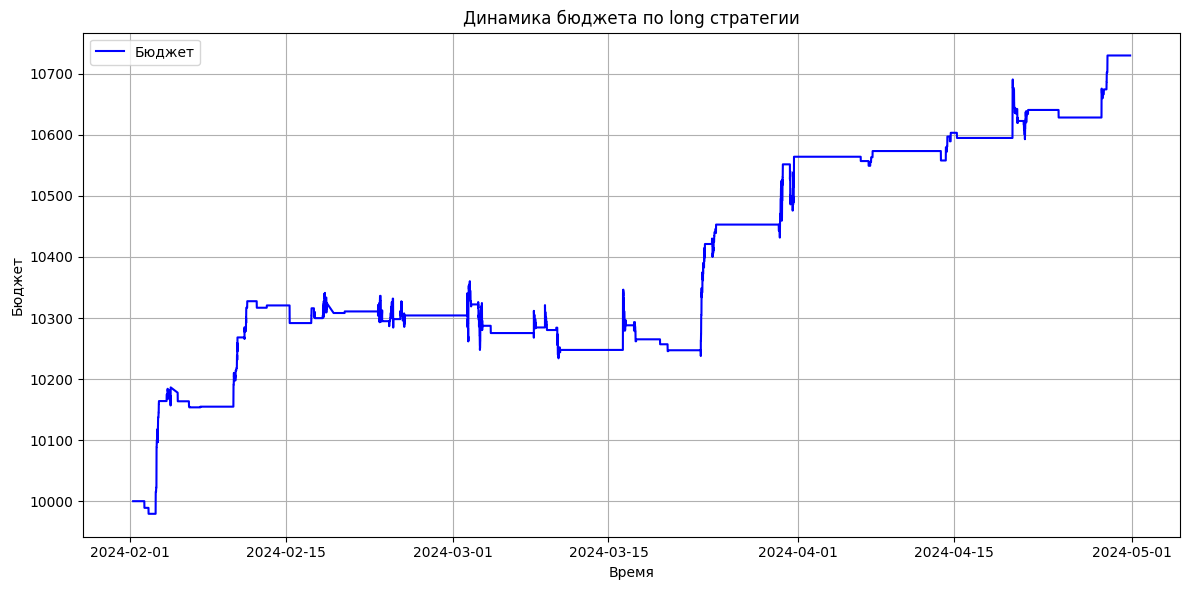

In [ ]:
visualise_long_budget("Gazprom_long_valid_diff_weights.csv")